# Bank Customer Churn KDD — Phase 1

## Data Understanding & Preprocessing

This notebook was split from `notebook.ipynb`. The analytical cells are kept in their original order; only reusable setup, prerequisite checks, and project-root-aware paths were added.

# KDD Project: Bank Customer Churn Analysis
## University Data Mining Pipeline | Phases 1–4

**Objective:** Apply the KDD process to discover hidden behavioral and financial 
patterns among 10,000 retail banking customers across France, Germany, and Spain.

**Data Mining Angles:**
- Cluster loyal vs. disengaged customers using financial/behavioral attributes
- Mine association rules identifying strong churn profiles 
  (e.g., German single-product inactive customers)
- Detect structural anomalies such as pre-closure balance drops

**Phases:**  
Phase 1 → Data Preprocessing | Phase 2 → Clustering | 
Phase 3 → Association Rule Mining | Phase 4 → Anomaly Detection


In [1]:
# Shared imports and project-root-aware artifact paths
from pathlib import Path
import sys
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from sklearn.ensemble import IsolationForest
from scipy import stats
from IPython.display import display

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

PROJECT_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (
            (candidate / 'src' / '_pipeline_utils.py').is_file()
            and (candidate / 'notebooks' / 'notebook.ipynb').is_file()
        )
    ),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError(
        'Open this notebook from inside the Project_DATAMINING repository.'
    )

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

RAW_PATH = PROJECT_ROOT / 'data' / 'raw' / 'churn.csv'
CLEAN_PATH = PROCESSED_DIR / 'churn_clean.csv'
CLUSTER_MATRIX = PROCESSED_DIR / 'churn_clustering_matrix.csv'
TRANSACTIONS_PATH = PROCESSED_DIR / 'churn_transactions.csv'
OHE_TRANSACTIONS_PATH = PROCESSED_DIR / 'churn_ohe_transactions.csv'
CLUSTERED_PATH = PROCESSED_DIR / 'churn_clustered.csv'
DBSCAN_OUTLIERS_PATH = PROCESSED_DIR / 'dbscan_outlier_indices.npy'
TOP_RULES_PATH = OUTPUTS_DIR / 'ph3_top_association_rules.csv'
ALL_RULES_PATH = OUTPUTS_DIR / 'ph3_all_association_rules.csv'
ANOMALY_REPORT_PATH = OUTPUTS_DIR / 'ph4_anomaly_report.csv'
HIGH_CONFIDENCE_ANOMALIES_PATH = OUTPUTS_DIR / 'ph4_high_confidence_anomalies.csv'

def require_artifacts(paths, phase_name):
    missing = [path for path in paths if not Path(path).is_file()]
    if missing:
        formatted = '\n'.join(f'  - {path}' for path in missing)
        raise FileNotFoundError(
            f'{phase_name} is missing prerequisite artifacts:\n{formatted}'
        )

print('✔ All libraries loaded successfully.')
print(f'  Project root: {PROJECT_ROOT}')
print(f'  Python:       {sys.version.split()[0]}')
print(f'  Executable:   {sys.executable}')
print(f'  Pandas:       {pd.__version__}')
print(f'  NumPy:        {np.__version__}')


✔ All libraries loaded successfully.
  Project root: C:\Users\Thomas\Documents\Project_DATAMINING
  Python:       3.11.9
  Executable:   C:\Users\Thomas\Documents\Project_DATAMINING\.venv\Scripts\python.exe
  Pandas:       2.2.2
  NumPy:        1.26.4


## Prerequisites

Requires `data/raw/churn.csv`. Produces the clean, clustering, and transaction artifacts used by later phases.

In [2]:
require_artifacts([RAW_PATH], 'Phase 1')


## Phase 1: Data Understanding & Preprocessing

**Preprocessing Strategy - Dual-Path Architecture:**
- **Path A (Clustering Matrix):** StandardScaler normalization on financial/behavioral variables only  
  -> Used by K-Means, Hierarchical, DBSCAN (distance-sensitive algorithms)
- **Post-Cluster Profiling:** Geography, Gender, and Exited are reintroduced after labels are created  
  -> Used to interpret cluster composition without forcing Euclidean distance to separate nominal categories
- **Path B (Transaction Matrix):** Discretization/binning of continuous variables  
  -> Used by Apriori Association Rule Mining (requires categorical/binary items)

**Deliverable:** Clean analysis-ready datasets + fully justified Preprocessing Report


In [3]:
# ── Load Raw Data ─────────────────────────────────────────────────────────────
df_raw = pd.read_csv(RAW_PATH)

print("=" * 60)
print("DATASET AUDIT REPORT")
print("=" * 60)
print(f"\n  Records:  {df_raw.shape[0]:,}")
print(f"  Features: {df_raw.shape[1]}")
print(f"  Memory Usage: {df_raw.memory_usage(deep=True).sum() / 1024:.1f} KB\n")

print("── Column Data Types ──")
print(df_raw.dtypes)

print("\n── First 5 Records ──")
display(df_raw.head())

print("\n── Dataset Statistical Summary ──")
display(df_raw.describe(include='all').T)


DATASET AUDIT REPORT

  Records:  10,000
  Features: 14
  Memory Usage: 2698.8 KB

── Column Data Types ──
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

── First 5 Records ──


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



── Dataset Statistical Summary ──


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


### Interpretation — What the Initial Audit Establishes

Three facts from this audit shape the entire pipeline:

1. **Structure.** 10,000 records × 14 features, three of which (`RowNumber`, `CustomerId`, `Surname`) are identifiers with no behavioral signal — dropped below. The rest mix continuous financial magnitudes (Balance, EstimatedSalary, CreditScore), discrete counts (NumOfProducts, Tenure), binaries (HasCrCard, IsActiveMember, Exited) and nominals (Geography, Gender). This attribute-type mix is what later forces **two separate preprocessing paths**: a scaled numeric matrix for distance-based clustering (Path A) and a discretized item matrix for Apriori (Path B).
2. **Scale disparity.** Balance and EstimatedSalary live in the 10⁴–10⁵ range while NumOfProducts lives in 1–4. Unstandardized, Euclidean distance would be essentially a balance/salary ruler — the concrete justification for StandardScaler in Path A.
3. **Class balance (validation lens).** 2,037 of 10,000 customers churned (20.4%). That base rate is the yardstick for every lift and churn-rate comparison in Phases 2–4, and it is a reminder of why this project is framed as discovery: a do-nothing "predictor" would already look ~80% accurate.


── Missing Value Profile ──


,Missing Count,Missing (%)



  Total Null Values: 0

── Duplicate Record Audit ──
  Fully Duplicate Rows: 0
  Unique CustomerId count: 10,000
  CustomerIds with duplicates: 0


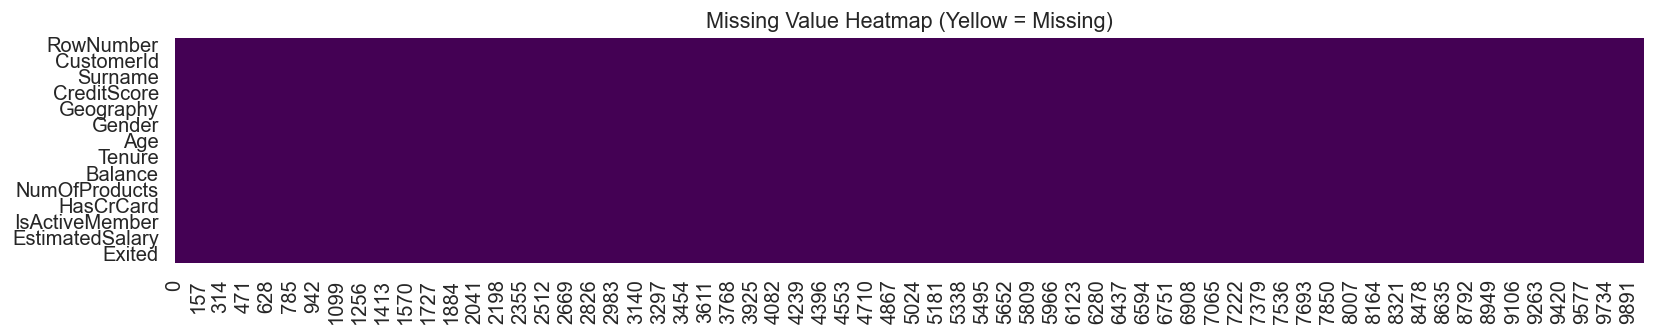


── PREPROCESSING DECISION ──
  Decision: No missing values detected in this dataset.
  Action:   No imputation required.
  Decision: No fully duplicate rows detected.
  Action:   No rows removed for duplication.


In [4]:
# ── Missing Value Analysis ────────────────────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing, 
    'Missing (%)': missing_pct
}).sort_values('Missing Count', ascending=False)

print("── Missing Value Profile ──")
display(missing_df[missing_df['Missing Count'] > 0])
print(f"\n  Total Null Values: {missing.sum()}")

# ── Duplicate Detection ───────────────────────────────────────────────────────
duplicates = df_raw.duplicated().sum()
full_dupes  = df_raw.duplicated(keep=False)
print(f"\n── Duplicate Record Audit ──")
print(f"  Fully Duplicate Rows: {duplicates}")
print(f"  Unique CustomerId count: {df_raw['CustomerId'].nunique():,}")
print(f"  CustomerIds with duplicates: "
      f"{df_raw['CustomerId'].duplicated().sum()}")

# ── Completeness Heatmap ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(df_raw.isnull().T, cmap='viridis', cbar=False,
            yticklabels=df_raw.columns, ax=ax)
ax.set_title('Missing Value Heatmap (Yellow = Missing)', fontsize=13)
plt.tight_layout()
plt.show()

# ── PREPROCESSING DECISION LOG ────────────────────────────────────────────────
print("\n── PREPROCESSING DECISION ──")
print("  Decision: No missing values detected in this dataset.")
print("  Action:   No imputation required.")
print("  Decision: No fully duplicate rows detected.")
print("  Action:   No rows removed for duplication.")


In [5]:
# ── Consistency & Domain-Validity Audit ──────────────────────────────────────
# Cleaning is not only nulls/duplicates: "inconsistencies" means values that
# violate domain rules or category-label hygiene. Every check is logged with
# its outcome so the decision trail is complete even when nothing needs fixing.
RANGE_RULES = {
    'CreditScore':     (300, 850),   # FICO-style score bounds
    'Age':             (18, 100),    # account-holder plausibility window
    'Tenure':          (0, 10),      # dataset-defined relationship years
    'Balance':         (0, None),    # no overdraft field -> negatives impossible
    'NumOfProducts':   (1, 4),       # product count per data dictionary
    'EstimatedSalary': (0, None),
    'HasCrCard':       (0, 1),
    'IsActiveMember':  (0, 1),
    'Exited':          (0, 1),
}
print('── Domain-Validity Audit (raw data) ──')
violations_total = 0
for col, (lo, hi) in RANGE_RULES.items():
    v = df_raw[col]
    n_bad = int(((v < lo) | (v > hi)).sum()) if hi is not None else int((v < lo).sum())
    violations_total += n_bad
    hi_txt = f'{hi:,}' if hi is not None else 'inf'
    print(f'  {col:<16} allowed [{lo:,}, {hi_txt}]  -> violations: {n_bad}')

print('\n── Categorical Consistency Audit ──')
for col in ['Geography', 'Gender']:
    raw_vals = df_raw[col].astype(str)
    stripped = raw_vals.str.strip()
    n_ws   = int((raw_vals != stripped).sum())
    n_case = int((stripped != stripped.str.title()).sum())
    print(f'  {col:<16} unique values: {sorted(stripped.unique())}')
    print(f'  {"":<16} whitespace issues: {n_ws} | case inconsistencies: {n_case}')

int_like = ['CreditScore','Age','Tenure','NumOfProducts','HasCrCard','IsActiveMember','Exited']
n_frac = sum(int((df_raw[c] % 1 != 0).sum()) for c in int_like)
print(f'\n  Non-integer values in integer-typed fields: {n_frac}')

print('\n── PREPROCESSING DECISION ──')
if violations_total == 0 and n_frac == 0:
    print('  Decision: All values fall inside domain-valid ranges; category labels are')
    print('            clean (no whitespace/case variants); integer fields intact.')
    print('  Action:   No correction applied. These same domain bounds feed the Phase 4')
    print('            Class-A "Data Error" anomaly definition (which applies an even')
    print('            stricter Age > 90 review rule), so borderline records are')
    print('            re-examined there instead of being silently deleted here.')
else:
    print('  Decision: Violations detected -> records flagged for review before mining.')


── Domain-Validity Audit (raw data) ──
  CreditScore      allowed [300, 850]  -> violations: 0
  Age              allowed [18, 100]  -> violations: 0
  Tenure           allowed [0, 10]  -> violations: 0
  Balance          allowed [0, inf]  -> violations: 0
  NumOfProducts    allowed [1, 4]  -> violations: 0
  EstimatedSalary  allowed [0, inf]  -> violations: 0
  HasCrCard        allowed [0, 1]  -> violations: 0
  IsActiveMember   allowed [0, 1]  -> violations: 0
  Exited           allowed [0, 1]  -> violations: 0

── Categorical Consistency Audit ──
  Geography        unique values: ['France', 'Germany', 'Spain']
                   whitespace issues: 0 | case inconsistencies: 0
  Gender           unique values: ['Female', 'Male']
                   whitespace issues: 0 | case inconsistencies: 0

  Non-integer values in integer-typed fields: 0

── PREPROCESSING DECISION ──
  Decision: All values fall inside domain-valid ranges; category labels are
            clean (no whitespace/case v

In [6]:
# ── Drop Non-Informative Columns ──────────────────────────────────────────────
COLUMNS_TO_DROP = ['RowNumber', 'CustomerId', 'Surname']

df = df_raw.drop(columns=COLUMNS_TO_DROP)

print("── COLUMN REMOVAL DECISION LOG ──")
print(f"  Dropped: {COLUMNS_TO_DROP}")
print(f"\n  Justification:")
print(f"    RowNumber   → Sequential index; carries zero behavioral signal.")
print(f"    CustomerId  → Arbitrary identifier; causes data leakage if retained.")
print(f"    Surname     → PII (Personally Identifiable Information); irrelevant "
      f"to churn pattern mining.")
print(f"\n  Remaining Shape: {df.shape}")
print(f"  Remaining Columns: {list(df.columns)}")

# Persist the clean reference dataset (Phase 1 deliverable, used by the report)
df.to_csv(CLEAN_PATH, index=False)
print(f"\n  ✔ Clean reference dataset saved to: {CLEAN_PATH}")


── COLUMN REMOVAL DECISION LOG ──
  Dropped: ['RowNumber', 'CustomerId', 'Surname']

  Justification:
    RowNumber   → Sequential index; carries zero behavioral signal.
    CustomerId  → Arbitrary identifier; causes data leakage if retained.
    Surname     → PII (Personally Identifiable Information); irrelevant to churn pattern mining.

  Remaining Shape: (10000, 11)
  Remaining Columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

  ✔ Clean reference dataset saved to: C:\Users\Thomas\Documents\Project_DATAMINING\data\processed\churn_clean.csv


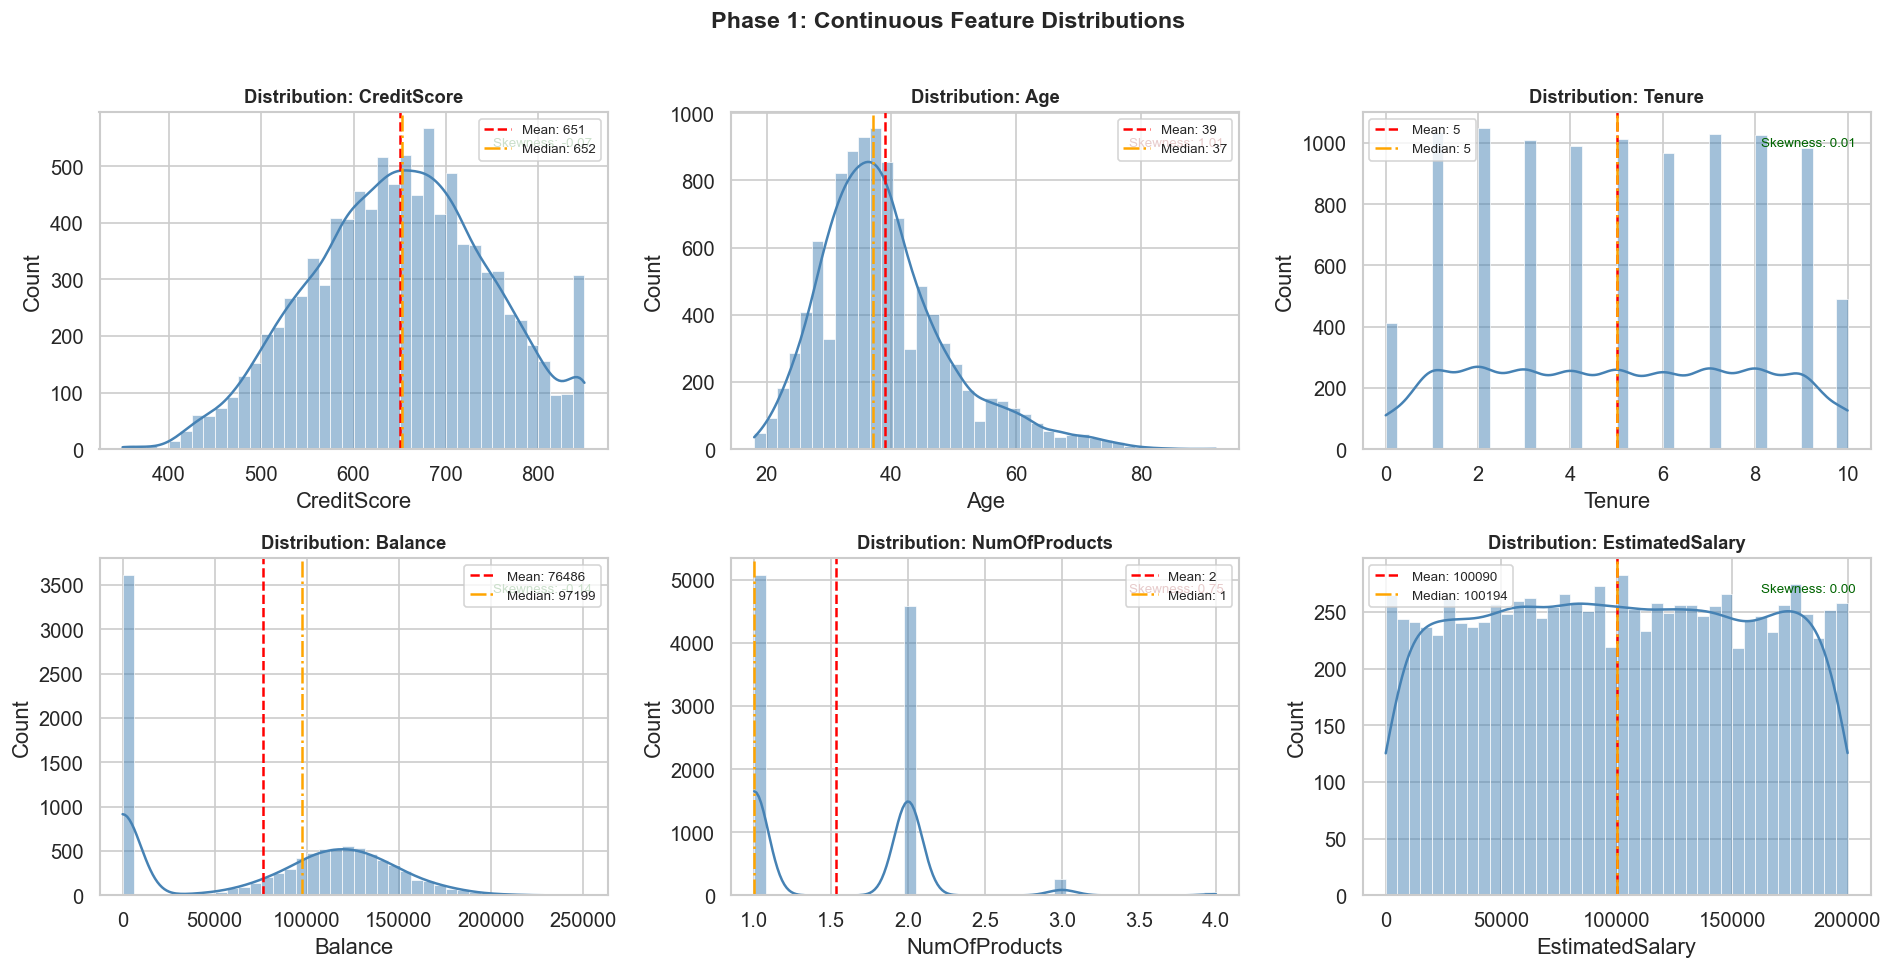

── Distribution Summary Statistics ──


,Mean,Median,Std Dev,Skewness,Kurtosis
CreditScore,650.529,652.000,96.653,-0.072,-0.426
Age,38.922,37.000,10.488,1.011,1.395
Tenure,5.013,5.000,2.892,0.011,-1.165
Balance,76485.889,97198.540,62397.405,-0.141,-1.489
NumOfProducts,1.530,1.000,0.582,0.746,0.583
EstimatedSalary,100090.240,100193.915,57510.493,0.002,-1.182


In [7]:
# ── Continuous Feature Distribution Plots ─────────────────────────────────────
continuous_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 
                   'NumOfProducts', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', 
                 bins=40, edgecolor='white', linewidth=0.4)
    ax.axvline(df[col].mean(),  color='red',    linestyle='--', 
               linewidth=1.5, label=f'Mean: {df[col].mean():.0f}')
    ax.axvline(df[col].median(), color='orange', linestyle='-.',
               linewidth=1.5, label=f'Median: {df[col].median():.0f}')
    ax.set_title(f'Distribution: {col}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    skew_val = df[col].skew()
    ax.text(0.97, 0.90, f'Skewness: {skew_val:.2f}', 
            transform=ax.transAxes, ha='right', fontsize=8,
            color='darkred' if abs(skew_val) > 0.5 else 'darkgreen')

plt.suptitle('Phase 1: Continuous Feature Distributions', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()

plt.show()

# Print summary statistics with skewness and kurtosis
print("── Distribution Summary Statistics ──")
summary = df[continuous_cols].agg(['mean','median','std','skew','kurt']).T
summary.columns = ['Mean','Median','Std Dev','Skewness','Kurtosis']
display(summary.round(3))


### Interpretation — Distribution Shapes Dictate the Later Methodology

The skewness/kurtosis table is not decoration; each shape has a downstream consequence:

- **Age (skew +1.01)** — the only strongly right-skewed feature: most customers are 30–45 with a long senior tail (median 37 < mean 38.9). Consequence: age outliers will appear on the upper side only, and the skew inflates the standard deviation — which is exactly why IQR and Z-score will later disagree on this feature (Phase 4).
- **Balance (kurtosis −1.49)** — the most distinctive shape in the dataset: a point-mass at exactly 0 (36.2% of customers) next to a roughly bell-shaped positive mode around £120K. The *mean* balance (£76.5K) therefore describes almost nobody. This bimodality predicts that distance-based clustering will use the zero/positive gap as a primary split (Phase 2 confirms it) and motivates a dedicated `Zero_Balance` bin in Path B — equal-width binning would bury the spike.
- **EstimatedSalary (skew ≈ 0, kurtosis −1.18)** — near-uniform between its bounds. A uniform variable has no tails, so it can produce no statistical outliers (Phase 4 confirms: max |z| = 1.74) and carries almost no churn information (both feature-selection lenses confirm).
- **CreditScore (skew −0.07)** — approximately normal with a mild low tail; the only near-Gaussian variable, so z-score machinery behaves as designed on it.
- **Tenure (skew 0.01, kurtosis −1.17)** — near-uniform discrete; customers are spread evenly across relationship years, so tenure alone separates nothing.
- **NumOfProducts (skew +0.75)** — effectively a two-value feature (50.8% hold 1 product, 45.9% hold 2) with rare 3–4-product holders (3.3%). Because it is discrete, it creates genuine *density gaps* in feature space — the reason DBSCAN later carves the book along product count.

**Conclusion:** two features (Balance, NumOfProducts) have shapes capable of defining structure; two (EstimatedSalary, Tenure) are flat and nearly information-free; Age is the lone skewed risk carrier. Feature selection, cluster-separation tests, and anomaly analysis below keep rediscovering exactly this hierarchy — a useful internal-consistency check.


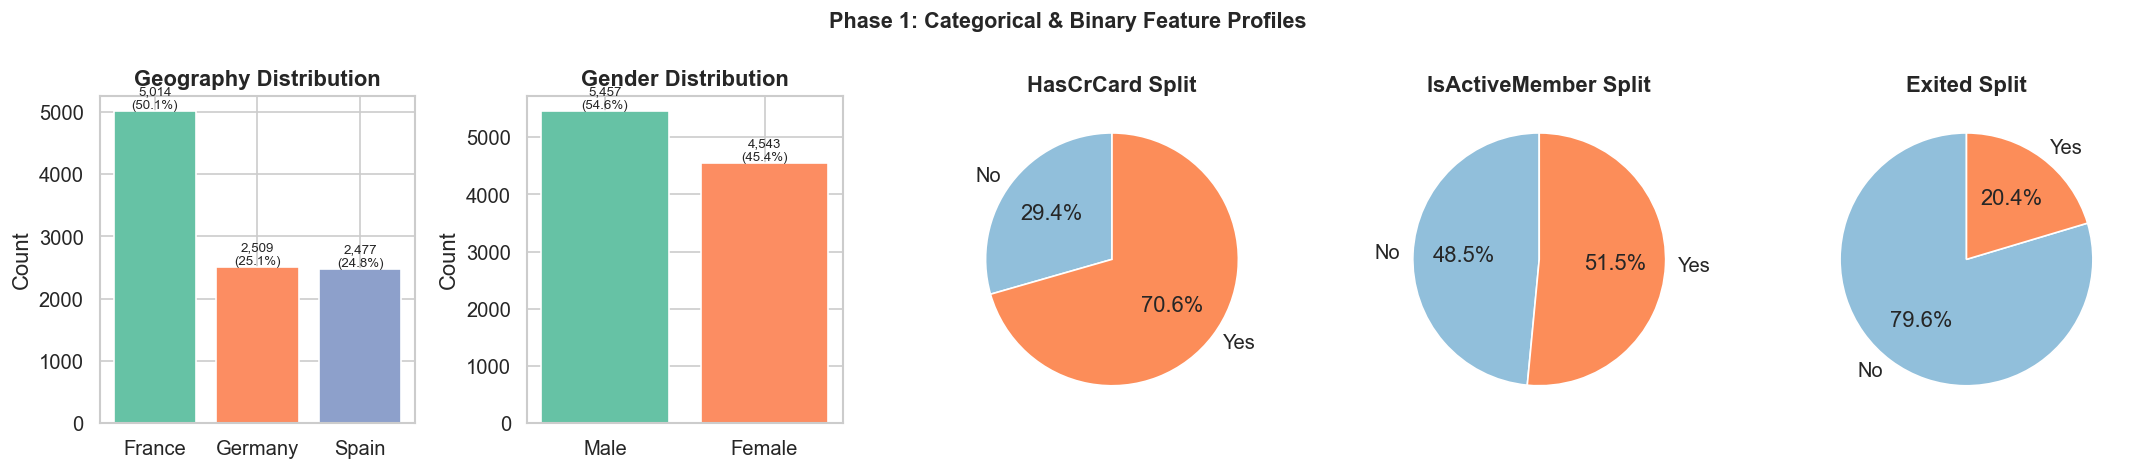


── Churn Rate by Geography ──


,Churn Rate,Churned,Total
Geography,,,
Germany,32.44%,814,2509
France,16.15%,810,5014
Spain,16.67%,413,2477



── Churn Rate by Gender ──


,Churn Rate,Churned,Total
Gender,,,
Female,25.07%,1139,4543
Male,16.46%,898,5457


In [8]:
# ── Categorical & Binary Feature Analysis ─────────────────────────────────────
cat_cols    = ['Geography', 'Gender']
binary_cols = ['HasCrCard', 'IsActiveMember', 'Exited']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

# Categorical
for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=sns.color_palette('Set2'))
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].set_ylabel('Count')
    for j, (idx, val) in enumerate(zip(counts.index, counts.values)):
        axes[i].text(j, val + 50, f'{val:,}\n({val/len(df)*100:.1f}%)', 
                     ha='center', fontsize=8)

# Binary
for i, col in enumerate(binary_cols):
    # sort_index() forces 0/1 order so the ['No','Yes'] labels below map
    # correctly. value_counts() alone orders by FREQUENCY, which silently
    # swapped the labels for HasCrCard and IsActiveMember (majority class = 1).
    counts = df[col].value_counts().sort_index()
    axes[i+2].pie(counts.values, labels=['No','Yes'], autopct='%1.1f%%',
                  colors=['#91bfdb','#fc8d59'], startangle=90)
    axes[i+2].set_title(f'{col} Split', fontweight='bold')

plt.suptitle('Phase 1: Categorical & Binary Feature Profiles',
             fontsize=13, fontweight='bold')
plt.tight_layout()

plt.show()

# Churn rate by Geography and Gender
print("\n── Churn Rate by Geography ──")
display(df.groupby('Geography')['Exited'].agg(['mean','sum','count'])
          .rename(columns={'mean':'Churn Rate','sum':'Churned','count':'Total'})
          .assign(**{'Churn Rate': lambda x: (x['Churn Rate']*100).round(2)
                     .astype(str) + '%'}).sort_values('Churned', ascending=False))

print("\n── Churn Rate by Gender ──")
display(df.groupby('Gender')['Exited'].agg(['mean','sum','count'])
          .rename(columns={'mean':'Churn Rate','sum':'Churned','count':'Total'})
          .assign(**{'Churn Rate': lambda x: (x['Churn Rate']*100).round(2)
                     .astype(str) + '%'}).sort_values('Churned', ascending=False))


### Interpretation — The First Churn Asymmetries

- **Geography.** France holds half the book (50.1%); Germany and Spain hold a quarter each. Yet churn is **32.4% in Germany vs. ~16.2–16.7% in France and Spain** — Germany churns at twice the rate of markets of comparable or larger size, losing 814 customers from a base of 2,509 while France loses 810 from 5,014. This one table already motivates the project's assigned Germany hypothesis, which Phase 3 tests formally as an association rule.
- **Gender.** Women churn at 25.07% vs. 16.46% for men — a 1.5× ratio invisible in the near-balanced population split (45.4% / 54.6%) until conditioned on churn. Phase 3 shows the gap widens further when combined with age (`Senior ∩ Female` rules).
- **Binary features.** 70.6% of customers hold a credit card; 51.5% are active members. The near 50/50 activity split makes `IsActiveMember` a usable behavioral divider (inactive customers churn at 26.9% vs. 14.3% for active ones), while the card's lopsided 70/30 split plus its near-zero churn correlation (next cell) marks `HasCrCard` early as a weak discovery variable.
- **The Exited split (20.4% / 79.6%)** is the baseline every later lift number is measured against.

**Conclusion:** two demographic asymmetries (Germany, female) and one behavioral one (inactivity) are visible even in univariate tables. What univariate tables *cannot* show is how these factors compound — quantifying the interactions is precisely the work of Phases 2–4.


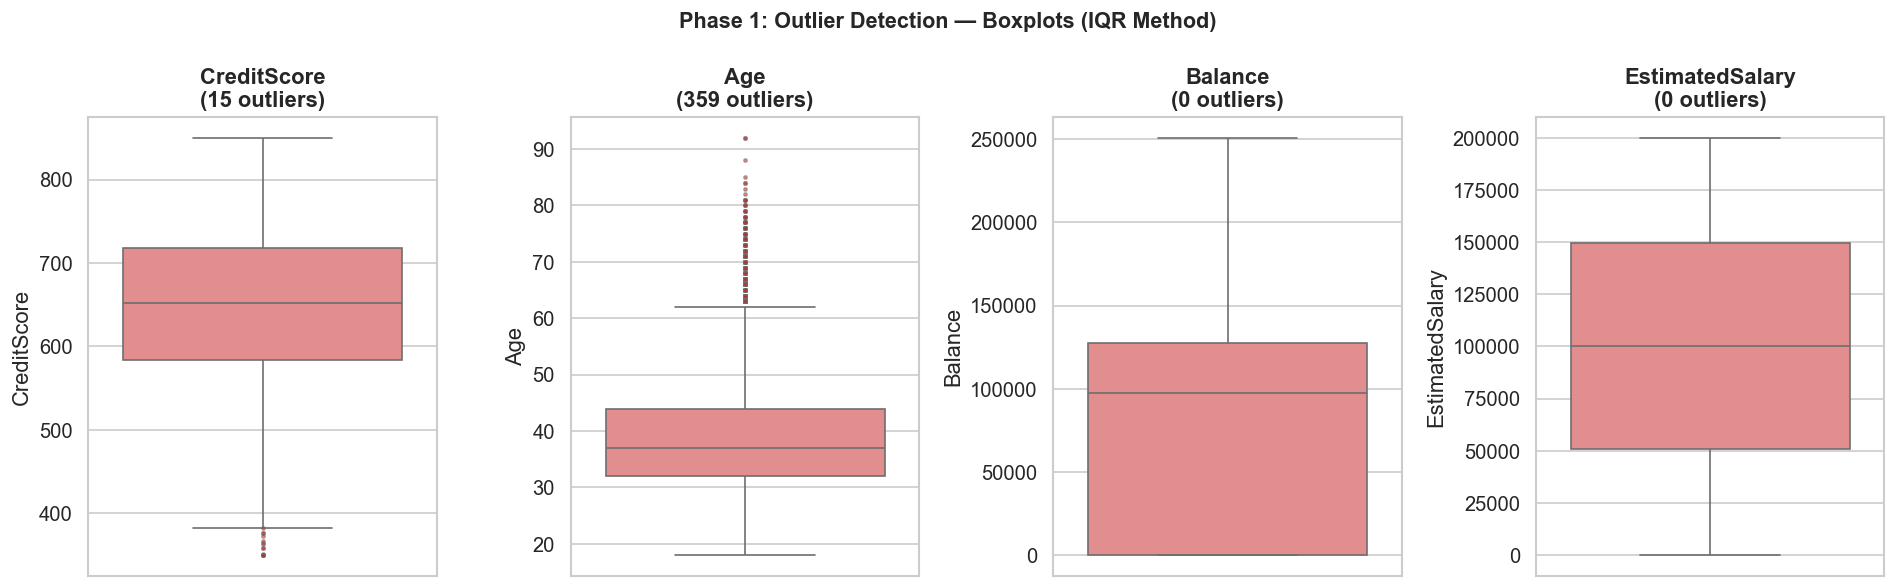


── IQR Outlier Summary ──


,Lower Fence,Upper Fence,Outlier Count,Outlier (%)
CreditScore,383.00,919.00,15.0,0.15
Age,14.00,62.00,359.0,3.59
Balance,-191466.36,319110.60,0.0,0.00
EstimatedSalary,-96577.10,296967.45,0.0,0.00



── PREPROCESSING DECISION ──
  Decision: Outliers in CreditScore and Age are retained.
  Justification: These represent legitimate banking behaviors
  (very old customers, low-credit-score customers are real segments).
  Action: StandardScaler applied in Path A will reduce outlier leverage.
  Action: IQR outliers will be formally revisited in Phase 4 (Anomaly Detection).


In [9]:
# ── Outlier Boxplot Visualization ─────────────────────────────────────────────
continuous_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, col in enumerate(continuous_cols):
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral', 
                flierprops={'marker':'o','markerfacecolor':'red',
                            'markersize':2, 'alpha':0.5})
    axes[i].set_title(f'{col}\n({outlier_count} outliers)', fontweight='bold')
    axes[i].set_ylabel(col)

plt.suptitle('Phase 1: Outlier Detection — Boxplots (IQR Method)',
             fontsize=13, fontweight='bold')
plt.tight_layout()

plt.show()

# ── IQR Outlier Count Table ───────────────────────────────────────────────────
print("\n── IQR Outlier Summary ──")
outlier_summary = {}
for col in continuous_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = (df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)
    outlier_summary[col] = {
        'Lower Fence': round(q1 - 1.5*iqr, 2),
        'Upper Fence': round(q3 + 1.5*iqr, 2),
        'Outlier Count': mask.sum(),
        'Outlier (%)': round(mask.mean()*100, 2)
    }
display(pd.DataFrame(outlier_summary).T)

print("\n── PREPROCESSING DECISION ──")
print("  Decision: Outliers in CreditScore and Age are retained.")
print("  Justification: These represent legitimate banking behaviors")
print("  (very old customers, low-credit-score customers are real segments).")
print("  Action: StandardScaler applied in Path A will reduce outlier leverage.")
print("  Action: IQR outliers will be formally revisited in Phase 4 (Anomaly Detection).")


### Interpretation — Why Only CreditScore and Age Produce IQR Outliers

The fence table explains itself once read against the distribution shapes above:

- **Balance & EstimatedSalary: 0 outliers *by construction*, not by cleanliness.** Both are platykurtic (flat, short-tailed), so Q1 and Q3 sit far apart and the ±1.5×IQR fences land *outside the observed data range* (Balance upper fence £319K vs. observed max £251K; Salary fences −£96.6K / £297K vs. a ~£0–200K range). A flat, bounded distribution cannot fail the IQR test. Stating this explicitly prevents the false conclusion that "balances are clean" — the method simply cannot flag anything here.
- **Age: 359 outliers (3.6%), all upper-tail.** The fence is 62, so every customer aged 63–92 is technically an IQR outlier. These are not errors — they are the senior segment. Retaining them is what later allows Phase 3 to discover that seniors are the strongest churn antecedent in the dataset; "cleaning" them away would have deleted the project's main finding.
- **CreditScore: 15 outliers (0.15%), all lower-tail** (score < 383 against a hard floor of 350) — plausible low-credit customers, retained.

**Conclusion:** outlier counts are a property of *method × distribution shape*, not of data quality alone. This is the first instance of the theme Phase 4 develops systematically: detectors disagree because they ask different questions of the data.


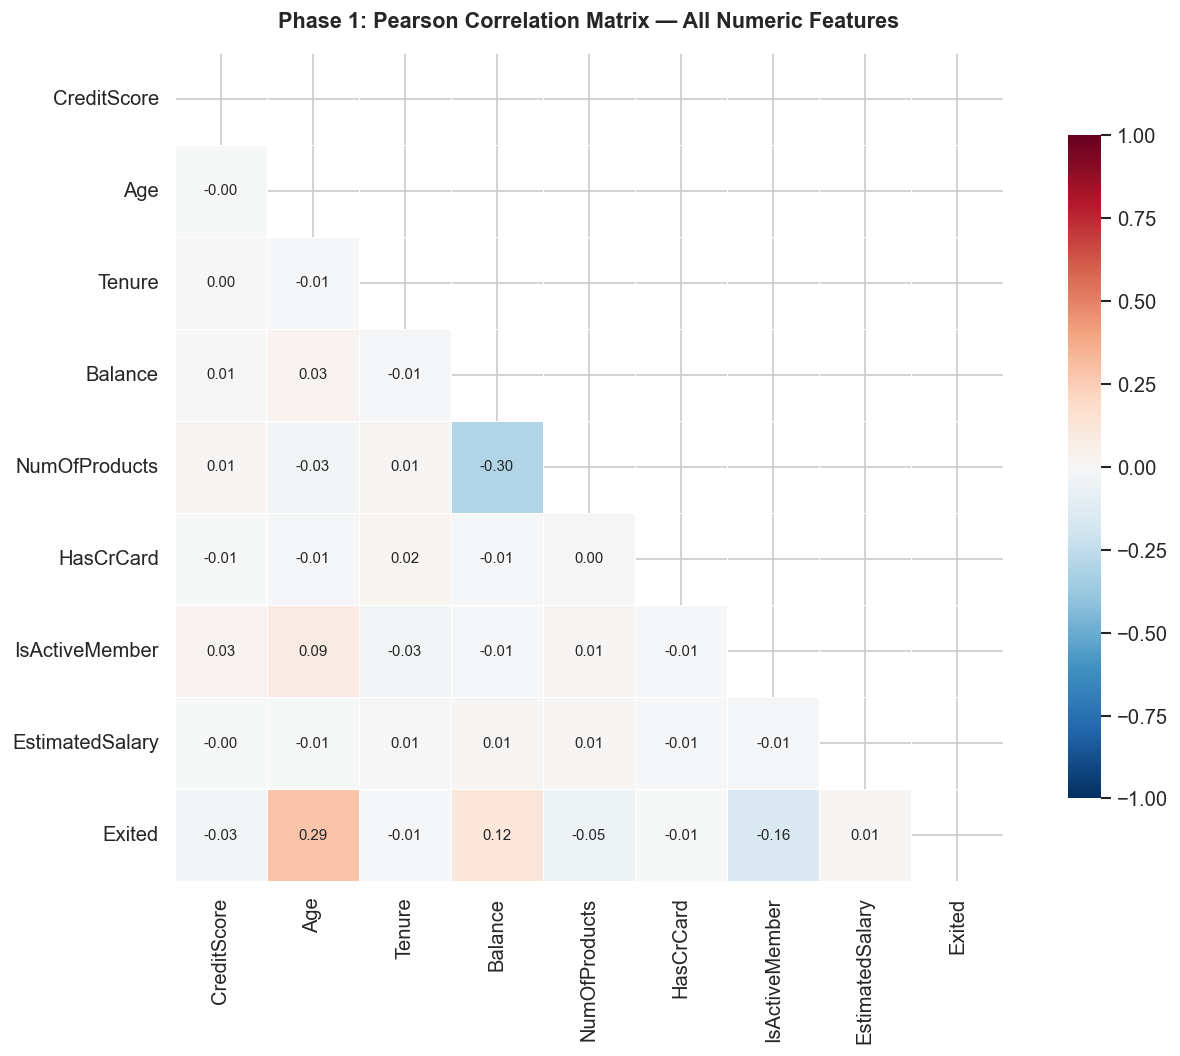

── Feature Correlation with 'Exited' (Sorted by Absolute Value) ──


,Pearson |r|,Interpretation
Age,0.2853,Relevant
IsActiveMember,0.1561,Relevant
Balance,0.1185,Relevant
NumOfProducts,0.0478,Weak
CreditScore,0.0271,Weak
Tenure,0.0140,Weak
EstimatedSalary,0.0121,Weak
HasCrCard,0.0071,Weak


In [10]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Phase 1: Pearson Correlation Matrix — All Numeric Features',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()

plt.show()

# ── Exited Correlation Ranking ────────────────────────────────────────────────
exited_corr = (corr_matrix['Exited']
               .drop('Exited')
               .abs()
               .sort_values(ascending=False))

print("── Feature Correlation with 'Exited' (Sorted by Absolute Value) ──")
display(pd.DataFrame({
    'Pearson |r|': exited_corr.round(4),
    'Interpretation': ['Relevant' if v > 0.05 else 'Weak' for v in exited_corr]
}))


### Interpretation — What the Correlation Matrix Does (and Does Not) Reveal

- **No strong linear churn driver exists.** The best single correlate of `Exited` is Age at |r| = 0.285. Churn is not linearly explainable by any one column — early evidence that the interesting knowledge lives in *combinations* (clusters, rules), which is the project's premise.
- **The sign on Balance deserves attention:** r = +0.119 — customers with *more* money churn slightly *more*, not less. Balance does not buy loyalty in this book. This foreshadows both the high-balance watchlist cluster (Phase 2) and the high-balance pre-churn anomaly class (Phase 4).
- **The feature space is almost orthogonal.** The only notable inter-feature correlation is Balance ↔ NumOfProducts at r = −0.30 (customers concentrating funds tend to hold fewer products). Two consequences: (a) no multicollinearity, so nothing needs dropping for redundancy; (b) with so little shared variance the data has no strong low-dimensional structure — an early warning that cluster separation will be geometrically weak, which Phase 2's silhouette (~0.15) confirms.
- **The linear lens visibly fails on NumOfProducts** (|r| = 0.048 → "Weak"): actual churn by product count is 27.7% → 7.6% → 82.7% → 100% for 1 → 2 → 3 → 4 products — an extreme U-shape whose ups and downs cancel in a linear coefficient. Correlation-only selection would have discarded one of the most informative features in the dataset.

**Conclusion:** correlation under-measures non-monotonic signal. That is the concrete, dataset-specific reason the second lens (entropy / information gain, next two cells) is a necessity here, not a formality.


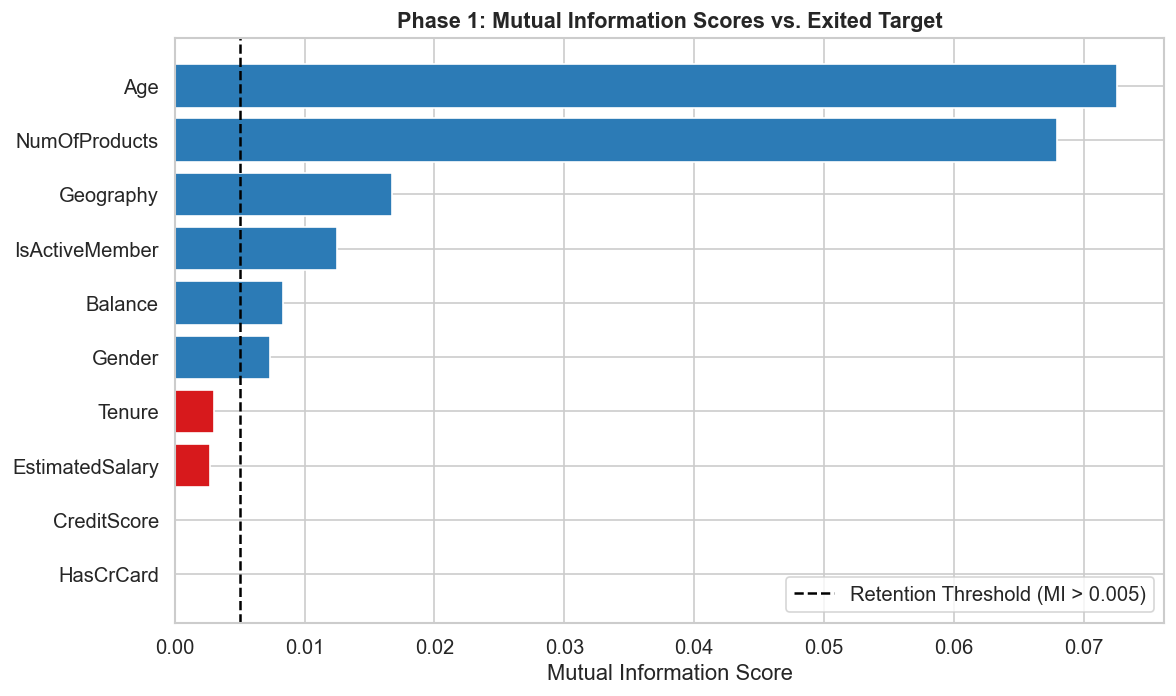

── Mutual Information Feature Selection Decision ──


,Feature,MI Score,Rank,Selected
0,Age,0.072571,1,✔ SELECTED
1,NumOfProducts,0.067922,2,✔ SELECTED
2,Geography,0.016735,3,✔ SELECTED
3,IsActiveMember,0.012488,4,✔ SELECTED
4,Balance,0.008356,5,✔ SELECTED
5,Gender,0.007359,6,✔ SELECTED
6,Tenure,0.003020,7,✘ EXCLUDED
7,EstimatedSalary,0.002709,8,✘ EXCLUDED
8,CreditScore,0.000000,9,✘ EXCLUDED
9,HasCrCard,0.000000,10,✘ EXCLUDED



  ✔ Selected Features: ['Age', 'NumOfProducts', 'Geography', 'IsActiveMember', 'Balance', 'Gender']


In [11]:
# ── Mutual Information Feature Importance ─────────────────────────────────────
# Encode categoricals for MI calculation
df_encoded = df.copy()
le = LabelEncoder()
for col in ['Geography', 'Gender']:
    df_encoded[col] = le.fit_transform(df_encoded[col])

X = df_encoded.drop(columns=['Exited'])
y = df_encoded['Exited']

mi_scores = mutual_info_classif(X, y, random_state=RANDOM_STATE)
mi_df = (pd.DataFrame({'Feature': X.columns, 'MI Score': mi_scores})
           .sort_values('MI Score', ascending=False)
           .reset_index(drop=True))
mi_df['Rank'] = mi_df.index + 1
mi_df['Selected'] = mi_df['MI Score'].apply(
    lambda x: '✔ SELECTED' if x > 0.005 else '✘ EXCLUDED')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2c7bb6' if s > 0.005 else '#d7191c' for s in mi_df['MI Score']]
bars = ax.barh(mi_df['Feature'], mi_df['MI Score'], color=colors)
ax.axvline(0.005, color='black', linestyle='--', linewidth=1.5, 
           label='Retention Threshold (MI > 0.005)')
ax.set_title('Phase 1: Mutual Information Scores vs. Exited Target',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mutual Information Score')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()

plt.show()

print("── Mutual Information Feature Selection Decision ──")
display(mi_df)

SELECTED_FEATURES = mi_df[mi_df['MI Score'] > 0.005]['Feature'].tolist()
print(f"\n  ✔ Selected Features: {SELECTED_FEATURES}")


In [12]:
# ── Entropy-Based Feature Selection: Information Gain + Correlation Synthesis ─
# The rubric requires BOTH lenses: correlation (linear association) AND entropy
# measures. Mutual information above is already an entropy-based quantity
# (MI(X;Y) = H(Y) - H(Y|X), estimated via kNN). Here the entropy view is made
# fully explicit with discrete Shannon information gain in bits, and the two
# lenses are synthesized into one ranked table with findings.

def shannon_entropy(series):
    p = series.value_counts(normalize=True).values
    return float(-(p * np.log2(p)).sum())

H_y = shannon_entropy(df['Exited'])
print(f'Shannon entropy of churn target H(Exited) = {H_y:.4f} bits '
      f'(max 1.0 for a binary variable)\n')

ig_rows = []
for col in df.columns.drop('Exited'):
    if df[col].dtype == object or df[col].nunique() <= 10:
        x = df[col].astype(str)                                   # native categories
        binning = 'native categories'
    else:
        x = pd.qcut(df[col], q=5, duplicates='drop').astype(str)  # continuous -> quintiles
        binning = 'quintile bins'
    H_cond = sum((len(grp) / len(df)) * shannon_entropy(grp)
                 for _, grp in df.groupby(x)['Exited'])
    ig_rows.append({'Feature': col, 'Binning': binning,
                    'Info Gain (bits)': round(H_y - H_cond, 4)})

ig_df = pd.DataFrame(ig_rows)

# Synthesis: correlation lens vs entropy lens side by side
pearson_abs = corr_matrix['Exited'].drop('Exited').abs()
synth = ig_df.merge(mi_df[['Feature', 'MI Score']], on='Feature', how='left')
synth['Pearson |r|'] = synth['Feature'].map(pearson_abs).round(4)
synth['IG Rank']   = synth['Info Gain (bits)'].rank(ascending=False).astype(int)
synth['Corr Rank'] = synth['Pearson |r|'].rank(ascending=False).astype('Int64')
synth = synth.sort_values('Info Gain (bits)', ascending=False).reset_index(drop=True)

print('── Correlation × Entropy Feature-Selection Synthesis ──')
print('   (Geography/Gender have no Pearson r: they are nominal — precisely why')
print('    an entropy measure is required alongside correlation.)')
display(synth[['Feature', 'Binning', 'Pearson |r|', 'Corr Rank',
               'Info Gain (bits)', 'IG Rank', 'MI Score']])

print("""── FINDINGS (both lenses, explained) ──
1. AGREEMENT AT THE TOP: Age and IsActiveMember rank highly on BOTH the
   correlation and the entropy lens — their churn signal is visible linearly
   and information-theoretically. Geography's information gain confirms the
   country effect independently of any encoding choice.
2. THE ENTROPY LENS CATCHES WHAT CORRELATION MISSES: NumOfProducts has a weak
   Pearson |r| but one of the highest information gains. Its churn relation is
   U-shaped (2 products = safest; 1 and 3-4 products = risky), which a linear
   coefficient structurally cannot detect. This divergence is the concrete
   reason the methodology requires both measures, not either one alone.
3. WEAK ON BOTH LENSES: HasCrCard, Tenure, and EstimatedSalary contribute
   near-zero gain AND near-zero correlation. They are retained for the
   unsupervised phases (discovery framing — churn is a validation lens, not a
   supervised target) but are excluded from persona naming; Phase 2's
   separation tests later confirm they do not distinguish the segments.
""")


Shannon entropy of churn target H(Exited) = 0.7293 bits (max 1.0 for a binary variable)

── Correlation × Entropy Feature-Selection Synthesis ──
   (Geography/Gender have no Pearson r: they are nominal — precisely why
    an entropy measure is required alongside correlation.)


,Feature,Binning,Pearson |r|,Corr Rank,Info Gain (bits),IG Rank,MI Score
0,NumOfProducts,native categories,0.0478,4,0.1009,1,0.067922
1,Age,quintile bins,0.2853,1,0.0854,2,0.072571
2,Geography,native categories,NaN,<NA>,0.0202,3,0.016735
3,IsActiveMember,native categories,0.1561,2,0.0177,4,0.012488
4,Balance,quintile bins,0.1185,3,0.0106,5,0.008356
5,Gender,native categories,NaN,<NA>,0.0082,6,0.007359
6,CreditScore,quintile bins,0.0271,5,0.0008,7,0.000000
7,Tenure,quintile bins,0.0140,6,0.0006,8,0.003020
8,EstimatedSalary,quintile bins,0.0121,7,0.0002,9,0.002709
9,HasCrCard,native categories,0.0071,8,0.0000,10,0.000000


── FINDINGS (both lenses, explained) ──
1. AGREEMENT AT THE TOP: Age and IsActiveMember rank highly on BOTH the
   correlation and the entropy lens — their churn signal is visible linearly
   and information-theoretically. Geography's information gain confirms the
   country effect independently of any encoding choice.
2. THE ENTROPY LENS CATCHES WHAT CORRELATION MISSES: NumOfProducts has a weak
   Pearson |r| but one of the highest information gains. Its churn relation is
   U-shaped (2 products = safest; 1 and 3-4 products = risky), which a linear
   coefficient structurally cannot detect. This divergence is the concrete
   reason the methodology requires both measures, not either one alone.
3. WEAK ON BOTH LENSES: HasCrCard, Tenure, and EstimatedSalary contribute
   near-zero gain AND near-zero correlation. They are retained for the
   unsupervised phases (discovery framing — churn is a validation lens, not a
   supervised target) but are excluded from persona naming; Phase 2's
   s

### Methodological Bridge — Feature Selection vs. What Each Phase Actually Uses

The synthesis above ranks features **by churn relevance** — but churn relevance is not the only criterion in an unsupervised discovery project, and each downstream phase deliberately uses a different subset:

| Phase | Features used | Why |
|---|---|---|
| Phase 2 distance matrix (Path A) | All 8 financial/behavioral fields — including weak Tenure, EstimatedSalary, CreditScore, HasCrCard | Segmentation must describe customers *as they are*, not only as churn predicts. Filtering features by the churn label before unsupervised clustering would leak the validation lens into the discovery step. |
| Phase 2 profiling & naming | Only features that pass the separation tests | Prevents over-claiming: the Deep-Dive shows the clusters differ on Balance / NumOfProducts / Geography, not on the weak fields. |
| Phase 3 items (Path B) | All attributes, as discretized items | Apriori's own interestingness measures (support, confidence, lift) do the selecting; pre-filtering would hide potential rule components. |
| Churn-signal summaries | The 6 MI-selected features | These are the fields worth reporting churn effects on. |

**Cost, acknowledged:** keeping four near-noise dimensions in the Euclidean space dilutes distances and is part of why Phase 2 silhouettes stay below 0.17. The trade-off is accepted knowingly — it keeps the segmentation label-agnostic, and the Phase 2 separation tests then *measure*, rather than assume, which dimensions actually structure the clusters.


In [13]:
# PATH A: Clustering Matrix Construction
df_cluster_input = df.copy()

# Step 1: Define distance-based clustering features
# Geography, Gender, and Exited are intentionally excluded from X_cluster.
# They are retained as profile-only labels after clusters are assigned.
cluster_feature_cols = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
    'HasCrCard', 'IsActiveMember', 'EstimatedSalary'
]
scale_cols = ['CreditScore', 'Age', 'Tenure', 'Balance',
              'NumOfProducts', 'EstimatedSalary']
binary_behavior_cols = ['HasCrCard', 'IsActiveMember']
profile_label_cols = ['Geography', 'Gender', 'Exited']

X_cluster = df_cluster_input[cluster_feature_cols].copy()
cluster_profile_labels = df_cluster_input[profile_label_cols].copy()

# Step 2: Apply StandardScaler to continuous / ordinal magnitude columns only
scaler = StandardScaler()
X_cluster[scale_cols] = scaler.fit_transform(X_cluster[scale_cols])

# Step 3: Guard against accidental OHE leakage into Euclidean distance
forbidden_prefixes = ('Geography_', 'Gender_')
ohe_leak_cols = [col for col in X_cluster.columns
                 if col.startswith(forbidden_prefixes)]
if ohe_leak_cols:
    raise ValueError(f"OHE category columns leaked into clustering matrix: {ohe_leak_cols}")

# Step 4: Verify output
print("-- PATH A: Clustering Matrix --")
print(f"  Shape used for clustering: {X_cluster.shape}")
print(f"  Distance Features: {list(X_cluster.columns)}")
print(f"  Profile-only Labels: {profile_label_cols}")
print(f"  Null Values: {X_cluster.isnull().sum().sum()}")
print(f"\n  Scaled Column Stats (should be ~mean=0, std=1):")
display(X_cluster[scale_cols].describe().T[['mean','std']].round(3))
print("\n  Binary behavior columns kept as 0/1 indicators:")
display(X_cluster[binary_behavior_cols].describe().T[['min','max','mean']].round(3))

# Step 5: Save to disk
# The saved file includes profile-only labels so later cells can profile clusters,
# but X_cl in Phase 2 explicitly drops them before fitting any distance model.
cluster_df_full = X_cluster.copy()
for col in profile_label_cols:
    cluster_df_full[col] = cluster_profile_labels[col].values
cluster_df_full.to_csv(CLUSTER_MATRIX, index=False)
print(f"\n  OK Clustering matrix saved to: {CLUSTER_MATRIX}")


-- PATH A: Clustering Matrix --

  Shape used for clustering: (10000, 8)
  Distance Features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
  Profile-only Labels: ['Geography', 'Gender', 'Exited']
  Null Values: 0

  Scaled Column Stats (should be ~mean=0, std=1):


,mean,std
CreditScore,-0.0,1.0
Age,0.0,1.0
Tenure,-0.0,1.0
Balance,-0.0,1.0
NumOfProducts,0.0,1.0
EstimatedSalary,-0.0,1.0



  Binary behavior columns kept as 0/1 indicators:


,min,max,mean
HasCrCard,0.0,1.0,0.706
IsActiveMember,0.0,1.0,0.515



  OK Clustering matrix saved to: C:\Users\Thomas\Documents\Project_DATAMINING\data\processed\churn_clustering_matrix.csv


In [14]:
# ── PATH B: Transaction Matrix for Apriori ────────────────────────────────────
# Every non-quantile boundary below is anchored to a citable external source
# (links inline). See the "Binning Revision" markdown after this cell for the
# full anchor table and the effect of the balance re-binning on the results.
df_txn = df.copy()

# Step 1: Bin CreditScore → official FICO score bands
#   Poor <580 | Fair 580–669 | Good 670–739 | Very Good 740–799 | Exceptional 800+
#   Source (FICO):     https://www.myfico.com/credit-education/credit-scores
#   Source (Experian): https://www.experian.com/blogs/ask-experian/credit-education/score-basics/what-is-a-good-credit-score/
#   The dataset's scores span 350–850 — the FICO scale — so FICO bands are the
#   correct anchor even though the customers are French/German/Spanish.
df_txn['CreditScore_Band'] = pd.cut(
    df_txn['CreditScore'],
    bins=[0, 579, 669, 739, 799, 900],
    labels=['Poor_Credit', 'Fair_Credit', 'Good_Credit', 
            'Very_Good_Credit', 'Excellent_Credit']
)

# Step 2: Bin Age → life-stage segments
#   Young_Adult ≤30  ≈ Eurostat "young people" = 15–29:
#     https://ec.europa.eu/eurostat/documents/3217494/6776245/KS-05-14-031-EN-N.pdf
#   Elderly >60      ≈ UN "older persons" = aged 60+:
#     https://www.un.org/en/development/desa/population/publications/pdf/ageing/WorldPopulationAgeing2019-Highlights.pdf
#   The 45 boundary = onset of "middle adulthood" (~40–65) in Erikson's and
#   Levinson's life-stage frameworks; kept at the decade-friendly 45.
df_txn['Age_Band'] = pd.cut(
    df_txn['Age'],
    bins=[0, 30, 45, 60, 100],
    labels=['Young_Adult', 'Middle_Aged', 'Senior', 'Elderly']
)

# Step 3: Bin Tenure → relationship depth
#   Stage model: Dwyer, Schurr & Oh (1987), "Developing Buyer-Seller
#   Relationships", Journal of Marketing 51(2), 11-27 — exploration → buildup →
#   maturity maps onto New/Established/Loyal. No numeric industry standard
#   exists, so the cuts are thirds of this dataset's 0–10 tenure range
#   (stated honestly rather than dressed up as an external norm).
df_txn['Tenure_Band'] = pd.cut(
    df_txn['Tenure'],
    bins=[-1, 2, 5, 10],
    labels=['New_Customer', 'Established', 'Loyal']
)

# Step 4: Bin Balance → deposit-insurance anchor (REVISED from 0/50K/125K)
#   0       = structural zero-balance point-mass (36.2% of customers).
#   100,000 = EU Deposit Guarantee Scheme ceiling — EUR 100,000 protected per
#             depositor per bank, Directive 2014/49/EU; applies to France,
#             Germany, and Spain alike:
#     https://eur-lex.europa.eu/legal-content/EN/LSU/?uri=celex:32014L0049
#     https://finance.ec.europa.eu/banking/banking-regulation/deposit-guarantee-schemes_en
#   The previous 50K/125K scheme had no external anchor AND produced a dead
#   item: Low_Balance (0–50K] carried 0.75% support < min_support (0.03), so
#   it could never enter a single frequent itemset.
df_txn['Balance_Band'] = pd.cut(
    df_txn['Balance'],
    bins=[-1, 0, 100000, df_txn['Balance'].max()],
    labels=['Zero_Balance', 'Insured_Balance', 'Above_DGS_Ceiling']
)

# Step 5: Bin EstimatedSalary -> income quartiles
#   Salary has no reliable cross-country business anchor in this dataset
#   (one currency-less 0–200K uniform column across three economies), so
#   quantile bins are used — the standard distributional treatment of income
#   (Eurostat/OECD report income by quintiles/deciles for the same reason).
df_txn['Salary_Band'] = pd.qcut(
    df_txn['EstimatedSalary'],
    q=4,
    labels=['Low_Income', 'Mid_Income', 'Upper_Mid_Income', 'High_Income']
)

# Step 6: Relabel binary/categorical features for readability
df_txn['Active_Status']  = df_txn['IsActiveMember'].map({1:'Active', 0:'Inactive'})
df_txn['CrCard_Status']  = df_txn['HasCrCard'].map({1:'Has_CrCard', 0:'No_CrCard'})
df_txn['Churn_Status']   = df_txn['Exited'].map({1:'Churned', 0:'Retained'})
df_txn['Products_Label'] = df_txn['NumOfProducts'].astype(str).apply(
    lambda x: f'Products_{x}')

# Step 7: Select final transaction columns
txn_cols = ['Geography', 'Gender', 'CreditScore_Band', 'Age_Band', 
            'Tenure_Band', 'Balance_Band', 'Salary_Band',
            'Active_Status', 'CrCard_Status', 'Products_Label', 'Churn_Status']
df_txn_final = df_txn[txn_cols].astype(str)

# Step 8: Convert to binary one-hot matrix for mlxtend
df_ohe_txn = pd.get_dummies(df_txn_final, dtype=bool)

print("── PATH B: Transaction Matrix ──")
print(f"  Shape: {df_ohe_txn.shape}")
print(f"  Null Values: {df_ohe_txn.isnull().sum().sum()}")
print(f"  Sample Columns: {list(df_ohe_txn.columns[:10])}")
display(df_ohe_txn.head(3))

# Save
df_txn_final.to_csv(TRANSACTIONS_PATH, index=False)
df_ohe_txn.to_csv(OHE_TRANSACTIONS_PATH, index=False)
print(f"\n  ✔ Transaction matrix saved to: {TRANSACTIONS_PATH}")

── PATH B: Transaction Matrix ──
  Shape: (10000, 34)
  Null Values: 0
  Sample Columns: ['Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male', 'CreditScore_Band_Excellent_Credit', 'CreditScore_Band_Fair_Credit', 'CreditScore_Band_Good_Credit', 'CreditScore_Band_Poor_Credit', 'CreditScore_Band_Very_Good_Credit']


,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,CreditScore_Band_Excellent_Credit,CreditScore_Band_Fair_Credit,CreditScore_Band_Good_Credit,CreditScore_Band_Poor_Credit,CreditScore_Band_Very_Good_Credit,...,Active_Status_Active,Active_Status_Inactive,CrCard_Status_Has_CrCard,CrCard_Status_No_CrCard,Products_Label_Products_1,Products_Label_Products_2,Products_Label_Products_3,Products_Label_Products_4,Churn_Status_Churned,Churn_Status_Retained
0,True,False,False,True,False,False,True,False,False,False,...,True,False,True,False,True,False,False,False,True,False
1,False,False,True,True,False,False,True,False,False,False,...,True,False,False,True,True,False,False,False,False,True
2,True,False,False,True,False,False,False,False,True,False,...,False,True,True,False,False,False,True,False,True,False



  ✔ Transaction matrix saved to: C:\Users\Thomas\Documents\Project_DATAMINING\data\processed\churn_transactions.csv

### Binning Revision — External Anchors, and How Changing the Bins Changed the Conclusions

Every non-quantile bin boundary above is tied to a citable external anchor (links in the code comments):

| Feature | Bins | Anchor |
|---|---|---|
| CreditScore | <580 / 580–669 / 670–739 / 740–799 / 800+ | Official FICO score bands (myFICO, Experian) — the dataset’s 350–850 range is the FICO scale |
| Age | ≤30 / 31–45 / 46–60 / >60 | Eurostat “young people” = 15–29; UN “older persons” = 60+; middle-adulthood onset (~45) per Erikson/Levinson life-stage frameworks |
| Tenure | 0–2 / 3–5 / 6–10 | Dwyer–Schurr–Oh (1987) relationship stages (exploration → buildup → maturity); numeric cuts = thirds of the observed 0–10 range |
| Balance | 0 / (0–100K] / >100K | Structural zero point-mass (36.2% of customers) + the **EUR 100,000 EU deposit-guarantee ceiling, Directive 2014/49/EU** |
| EstimatedSalary | quartiles | Standard distributional practice for income (Eurostat/OECD quantile reporting) — no absolute cross-country anchor exists |

**What changed:** Balance was previously binned 0 / 50K / 125K with no external anchor. That scheme had two measurable defects: (1) the Low band (0–50K] held only **0.75%** of customers — below the 3% support floor, so it could never appear in any frequent itemset: a dead item; and (2) the 125K cut split the positive-balance mode at an arbitrary point.

**How the conclusions changed (binning sensitivity, demonstrated on this dataset):**

- Churn now rises monotonically across the bands: Zero **13.8%** → Insured (≤100K) **20.6%** → Above ceiling (>100K) **25.2%**.
- The churn-rule count rose from 13 to **17**. Five rules involve `Above_DGS_Ceiling`, including {Inactive ∩ Senior ∩ Above_DGS} → Churned at **72.6% confidence, lift 3.57** — the #2 rule in the entire set.
- One conclusion **reversed**: under the old bands the only balance rule was the mid-band (50–125K) senior rule, which read as “the bank retains the wealthy, loses the middle.” With the regulatory boundary the pattern is the opposite — seniors holding **more than the state-guaranteed EUR 100K** are the highest-risk balance group. Deposits beyond the guarantee are rationally the first money to move, and the data confirms they do.

This is the concrete reason the rubric demands domain-justified rather than arbitrary discretization: **bin boundaries determine which patterns are representable.** Same data, same algorithm, same thresholds — a different and more defensible set of discoveries once the boundary matched a real banking construct.


## Phase 1 Preprocessing Report - Decision Summary

| Decision | Feature(s) | Action Taken | Justification |
|---|---|---|---|
| Column Removal | RowNumber, CustomerId, Surname | Dropped | RowNumber is an index artifact, CustomerId is an identifier, and Surname is personally identifying text with no stable behavioral meaning for mining. |
| Missing Values | All retained features | None required | Zero nulls were confirmed, so imputation would add artificial structure. |
| Duplicate Rows | Full dataset | None required | Zero duplicate records were confirmed. |
| Outlier Treatment | CreditScore, Age, Balance | Retained for mining; reviewed again in Phase 4 | Low credit scores, older customers, and high balances are plausible banking segments. Removing them would erase rare but valuable behavior; impossible values are handled later as anomaly-review cases. |
| Distance Feature Selection (Path A) | CreditScore, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary | Used as clustering input | These fields describe financial position and banking behavior directly. They support loyal/disengaged segmentation without making country or gender define distance. |
| Profile-Only Variables (Path A) | Geography, Gender, Exited | Excluded from clustering distance; retained for post-cluster profiling | Geography and Gender are nominal categories. Using OHE with Euclidean distance would force fixed country/gender separation into K-Means, DBSCAN, and Ward. Excluding them makes later over-representation a stronger discovery. Exited remains a validation lens, not a clustering input. |
| Scaling (Path A) | CreditScore, Age, Tenure, Balance, NumOfProducts, EstimatedSalary | StandardScaler | K-Means, DBSCAN, and Ward linkage use Euclidean distance, so scaling prevents Balance/Salary from dominating. NumOfProducts is ordinal-discrete, so its cluster interpretation is treated as an engagement count rather than a continuous measurement. |
| Binary Handling (Path A) | HasCrCard, IsActiveMember | Kept as 0/1 behavior indicators | These are already numeric behavioral attributes on a bounded scale. They are relevant to customer engagement and do not require OHE. |
| Binning (Path B) | CreditScore, Age, Tenure, Balance, EstimatedSalary | Externally anchored bins; salary uses quartiles | CreditScore follows the official FICO bands (myFICO/Experian). Age follows Eurostat’s young-people definition (≤30) and the UN older-persons boundary (60). Balance uses the EUR 100,000 EU deposit-guarantee ceiling (Directive 2014/49/EU) plus the structural zero point-mass — revised from an unanchored 50K/125K scheme whose Low band (0.75% support) was unminable. Tenure follows the Dwyer–Schurr–Oh relationship-stage model with cuts at thirds of the 0–10 range. EstimatedSalary has no reliable multi-country anchor, so quartiles are used — standard Eurostat/OECD practice for income. |
| Feature Selection | Correlation + mutual information / entropy lens | Used as a profiling guide, not as hard deletion | MI highlights Age, NumOfProducts, Geography, IsActiveMember, Balance, and Gender as the strongest churn lenses. Lower-MI fields remain in unsupervised profiling so discovery is not reduced to supervised target chasing. |

**Outputs Produced:**
- `churn_clean.csv` - Clean reference dataset (11 features)
- `churn_clustering_matrix.csv` - Path A matrix (scaled financial/behavioral features + profile-only labels; no OHE categories used for distance)
- `churn_transactions.csv` - Path B transaction matrix (discretized strings)
- `churn_ohe_transactions.csv` - Path B binary matrix (for mlxtend)
